# Real GWAS Gene Annotation

This project demonstrates how genomic variants can be linked to real human genes using Ensembl gene coordinates.

The project uses a small illustrative dataset and focuses on the basic annotation workflow:

1. Load variant coordinates.
2. Load gene coordinates.
3. Match variants to genes on the same chromosome.
4. Identify variants that fall within gene intervals.
5. Summarise the annotated results.

The example is educational and does not represent a validated disease association analysis.

In [1]:
import pandas as pd

# Small illustrative set of human genomic variants
variant_data = {
    "SNP": ["rs429358", "rs7412", "rs1801133"],
    "CHR": [19, 19, 1],
    "BP": [44908684, 44908822, 11796321],
    "P": [1e-10, 2e-8, 0.0004]
}

variants_df = pd.DataFrame(variant_data)

variants_df

,SNP,CHR,BP,P
0,rs429358,19,44908684,1.000000e-10
1,rs7412,19,44908822,2.000000e-08
2,rs1801133,1,11796321,4.000000e-04


In [3]:
# Real human gene coordinates from GRCh38
gene_data = {
    "GENE": ["APOE", "MTHFR"],
    "CHR": [19, 1],
    "START": [44905729, 11785721],
    "END": [44909393, 11788721]
}

genes_df = pd.DataFrame(gene_data)

genes_df

,GENE,CHR,START,END
0,APOE,19,44905729,44909393
1,MTHFR,1,11785721,11788721


In [4]:
def annotate_variants(variants, genes):
    annotations = []

    for _, variant in variants.iterrows():
        matches = genes[
            (genes["CHR"] == variant["CHR"]) &
            (genes["START"] <= variant["BP"]) &
            (genes["END"] >= variant["BP"])
        ]

        if len(matches) > 0:
            for _, gene in matches.iterrows():
                annotations.append({
                    "SNP": variant["SNP"],
                    "CHR": variant["CHR"],
                    "BP": variant["BP"],
                    "P": variant["P"],
                    "GENE": gene["GENE"]
                })
        else:
            annotations.append({
                "SNP": variant["SNP"],
                "CHR": variant["CHR"],
                "BP": variant["BP"],
                "P": variant["P"],
                "GENE": "No overlapping gene"
            })

    return pd.DataFrame(annotations)


annotated_df = annotate_variants(variants_df, genes_df)

annotated_df

,SNP,CHR,BP,P,GENE
0,rs429358,19,44908684,1.000000e-10,APOE
1,rs7412,19,44908822,2.000000e-08,APOE
2,rs1801133,1,11796321,4.000000e-04,No overlapping gene


In [5]:
import requests

ensembl_url = "https://rest.ensembl.org"

response = requests.get(
    f"{ensembl_url}/lookup/symbol/homo_sapiens/APOE",
    headers={"Content-Type": "application/json"}
)

response.status_code

200

In [6]:
apoe_response = requests.get(
    f"{ensembl_url}/lookup/symbol/homo_sapiens/APOE",
    headers={"Content-Type": "application/json"}
)

apoe_data = apoe_response.json()

apoe_data

{'canonical_transcript': 'ENST00000252486.9',
 'object_type': 'Gene',
 'source': 'ensembl_havana',
 'start': 44903787,
 'logic_name': 'ensembl_havana_gene_homo_sapiens',
 'display_name': 'APOE',
 'version': 12,
 'seq_region_name': '19',
 'description': 'apolipoprotein E [Source:HGNC Symbol;Acc:HGNC:613]',
 'biotype': 'protein_coding',
 'id': 'ENSG00000130203',
 'end': 44909396,
 'db_type': 'core',
 'assembly_name': 'GRCh38',
 'strand': 1,
 'species': 'homo_sapiens'}

In [7]:
print("Gene:", apoe_data["display_name"])
print("Chromosome:", apoe_data["seq_region_name"])
print("Start:", apoe_data["start"])
print("End:", apoe_data["end"])
print("Assembly:", apoe_data["assembly_name"])

Gene: APOE
Chromosome: 19
Start: 44903787
End: 44909396
Assembly: GRCh38


In [8]:
# Replace the manually entered APOE coordinates with Ensembl coordinates

genes_df.loc[genes_df["GENE"] == "APOE", "CHR"] = int(
    apoe_data["seq_region_name"]
)

genes_df.loc[genes_df["GENE"] == "APOE", "START"] = apoe_data["start"]

genes_df.loc[genes_df["GENE"] == "APOE", "END"] = apoe_data["end"]

genes_df

,GENE,CHR,START,END
0,APOE,19,44903787,44909396
1,MTHFR,1,11785721,11788721


In [9]:
annotated_df = annotate_variants(variants_df, genes_df)

annotated_df

,SNP,CHR,BP,P,GENE
0,rs429358,19,44908684,1.000000e-10,APOE
1,rs7412,19,44908822,2.000000e-08,APOE
2,rs1801133,1,11796321,4.000000e-04,No overlapping gene


In [10]:
mthfr_response = requests.get(
    f"{ensembl_url}/lookup/symbol/homo_sapiens/MTHFR",
    headers={"Content-Type": "application/json"}
)

mthfr_data = mthfr_response.json()

print("Gene:", mthfr_data["display_name"])
print("Chromosome:", mthfr_data["seq_region_name"])
print("Start:", mthfr_data["start"])
print("End:", mthfr_data["end"])
print("Assembly:", mthfr_data["assembly_name"])

Gene: MTHFR
Chromosome: 1
Start: 11785723
End: 11806455
Assembly: GRCh38


In [11]:
# Replace the manually entered MTHFR coordinates with Ensembl coordinates

genes_df.loc[genes_df["GENE"] == "MTHFR", "CHR"] = int(
    mthfr_data["seq_region_name"]
)

genes_df.loc[genes_df["GENE"] == "MTHFR", "START"] = mthfr_data["start"]

genes_df.loc[genes_df["GENE"] == "MTHFR", "END"] = mthfr_data["end"]

genes_df

,GENE,CHR,START,END
0,APOE,19,44903787,44909396
1,MTHFR,1,11785723,11806455


In [12]:
annotated_df = annotate_variants(variants_df, genes_df)

annotated_df

,SNP,CHR,BP,P,GENE
0,rs429358,19,44908684,1.000000e-10,APOE
1,rs7412,19,44908822,2.000000e-08,APOE
2,rs1801133,1,11796321,4.000000e-04,MTHFR


In [13]:
# Create a concise annotation summary

annotation_summary = annotated_df[
    ["SNP", "CHR", "BP", "P", "GENE"]
].copy()

annotation_summary["Significant"] = annotation_summary["P"] < 5e-8

annotation_summary

,SNP,CHR,BP,P,GENE,Significant
0,rs429358,19,44908684,1.000000e-10,APOE,True
1,rs7412,19,44908822,2.000000e-08,APOE,True
2,rs1801133,1,11796321,4.000000e-04,MTHFR,False


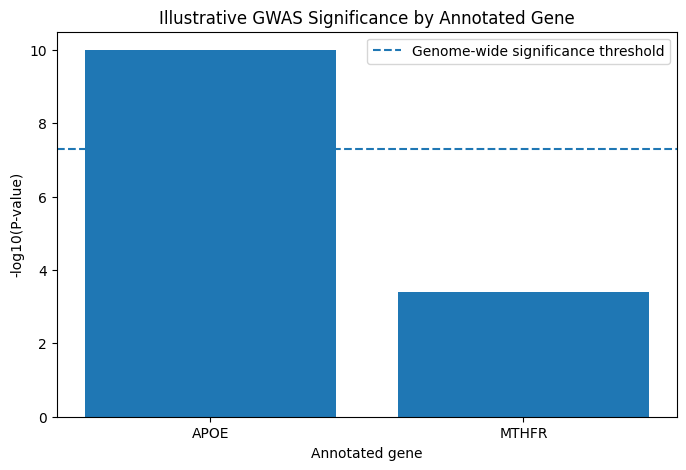

In [14]:
import matplotlib.pyplot as plt

plot_df = annotation_summary.copy()

plot_df["-log10(P)"] = -__import__("numpy").log10(plot_df["P"])

plt.figure(figsize=(8, 5))

plt.bar(plot_df["GENE"], plot_df["-log10(P)"])

plt.axhline(
    -__import__("numpy").log10(5e-8),
    linestyle="--",
    label="Genome-wide significance threshold"
)

plt.xlabel("Annotated gene")
plt.ylabel("-log10(P-value)")
plt.title("Illustrative GWAS Significance by Annotated Gene")
plt.legend()
plt.show()

## Conclusion

This project demonstrated how genomic variants can be annotated to real human genes using genomic coordinates retrieved from the Ensembl REST API.

The illustrative variants were mapped as follows:

- rs429358 → APOE
- rs7412 → APOE
- rs1801133 → MTHFR

The analysis also classified variants according to an illustrative genome-wide significance threshold of 5 × 10⁻⁸.

This project is educational. The p-values were simulated for demonstration and do not represent validated disease associations. A real GWAS annotation workflow would also consider variant alleles, transcript choice, coding consequences, regulatory regions, linkage disequilibrium, and disease-specific evidence.